## Module 1 Project: Initial Data Exploration for task 1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib import dates as mdates
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving polls_us_election_2016 (1).csv to polls_us_election_2016 (1).csv


In [ ]:
df = pd.read_csv('polls_us_election_2016 (1).csv')
print(df.shape)
df.head()

(4208, 15)


,state,startdate,enddate,pollster,grade,samplesize,population,rawpoll_clinton,rawpoll_trump,rawpoll_johnson,rawpoll_mcmullin,adjpoll_clinton,adjpoll_trump,adjpoll_johnson,adjpoll_mcmullin
0,U.S.,2016-11-03,2016-11-06,ABC News/Washington Post,A+,2220.0,lv,47.00,43.00,4.00,NaN,45.20163,41.72430,4.626221,NaN
1,U.S.,2016-11-01,2016-11-07,Google Consumer Surveys,B,26574.0,lv,38.03,35.69,5.46,NaN,43.34557,41.21439,5.175792,NaN
2,U.S.,2016-11-02,2016-11-06,Ipsos,A-,2195.0,lv,42.00,39.00,6.00,NaN,42.02638,38.81620,6.844734,NaN
3,U.S.,2016-11-04,2016-11-07,YouGov,B,3677.0,lv,45.00,41.00,5.00,NaN,45.65676,40.92004,6.069454,NaN
4,U.S.,2016-11-03,2016-11-06,Gravis Marketing,B-,16639.0,rv,47.00,43.00,3.00,NaN,46.84089,42.33184,3.726098,NaN


In [ ]:
data_dictionary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.values
})

data_dictionary

,Variable,Data Type
0,state,object
1,startdate,object
2,enddate,object
3,pollster,object
4,grade,object
5,samplesize,float64
6,population,object
7,rawpoll_clinton,float64
8,rawpoll_trump,float64
9,rawpoll_johnson,float64


In [ ]:
data_dictionary["Description"] = [
    "State where the poll was conducted",
    "Poll start date",
    "Poll end date",
    "Polling organization",
    "Quality grade of the poll",
    "Number of participants in the poll",
    "Population group surveyed",
    "Raw poll percentage for Clinton",
    "Raw poll percentage for Trump",
    "Raw poll percentage for Johnson",
    "Raw poll percentage for McMullin",
    "Adjusted poll percentage for Clinton",
    "Adjusted poll percentage for Trump",
    "Adjusted poll percentage for Johnson",
    "Adjusted poll percentage for McMullin"
]
data_dictionary

,Variable,Data Type,Description
0,state,object,State where the poll was conducted
1,startdate,object,Poll start date
2,enddate,object,Poll end date
3,pollster,object,Polling organization
4,grade,object,Quality grade of the poll
5,samplesize,float64,Number of participants in the poll
6,population,object,Population group surveyed
7,rawpoll_clinton,float64,Raw poll percentage for Clinton
8,rawpoll_trump,float64,Raw poll percentage for Trump
9,rawpoll_johnson,float64,Raw poll percentage for Johnson


In [ ]:
import pandas as pd
important_variables = pd.DataFrame({
    "Variable": [
        "state",
        "startdate",
        "enddate",
        "pollster",
        "grade",
        "samplesize",
        "rawpoll_clinton",
        "rawpoll_trump",
        "adjpoll_clinton",
        "adjpoll_trump",
        "population",
        "raw_margin_clinton_trump",
        "adj_margin_clinton_trump"
    ],

    "Description": [
        "State where the poll was conducted",
        "Date when the poll started",
        "Date when the poll ended",
        "Polling organization",
        "Poll quality grade",
        "Number of participants surveyed",
        "Raw support percentage for Clinton",
        "Raw support percentage for Trump",
        "Adjusted support percentage for Clinton",
        "Adjusted support percentage for Trump",
        "Type of population surveyed",
        "Difference between Clinton's raw polling percentage and Trump's raw polling percentage",
        "Difference between Clinton's adjusted polling percentage and Trump's adjusted polling percentage"
    ],

    "Justification": [
        "Helps identify geographic voting trends",
        "Helps place the beginning of each poll in the campaign timeline",
        "Helps place each poll in the campaign timeline",
        "Different pollsters may use different methods",
        "Gives context about the pollster’s overall quality rating",
        "Larger samples generally provide more stable estimates, although sample size alone does not determine poll quality",
        "Used to analyze Clinton’s adjusted polling estimate",
        "Used to analyze Trump’s adjusted polling estimate",
        "Provides corrected estimates for Clinton",
        "Provides corrected estimates for Trump",
        "Helps understand which group was surveyed (adults, registered voters, likely voters, etc.)",
        "Helps compare the two main candidates directly using the original poll results",
        "Central variable for analyzing who is leading after polling adjustments"
    ]
})

important_variables
important_variables["Data Type"] = [
    "object",
    "object",
    "object",
    "object",
    "object",
    "float64",
    "float64",
    "float64",
    "float64",
    "float64",
    "object",
    "float64",
    "float64"
]

important_variables
important_variables.style.set_properties(**{
    'text-align': 'left'
})

,Variable,Description,Justification,Data Type
0,state,State where the poll was conducted,Helps identify geographic voting trends,object
1,startdate,Date when the poll started,Helps place the beginning of each poll in the campaign timeline,object
2,enddate,Date when the poll ended,Helps place each poll in the campaign timeline,object
3,pollster,Polling organization,Different pollsters may use different methods,object
4,grade,Poll quality grade,Gives context about the pollster’s overall quality rating,object
5,samplesize,Number of participants surveyed,"Larger samples generally provide more stable estimates, although sample size alone does not determine poll quality",float64
6,rawpoll_clinton,Raw support percentage for Clinton,Used to analyze Clinton’s adjusted polling estimate,float64
7,rawpoll_trump,Raw support percentage for Trump,Used to analyze Trump’s adjusted polling estimate,float64
8,adjpoll_clinton,Adjusted support percentage for Clinton,Provides corrected estimates for Clinton,float64
9,adjpoll_trump,Adjusted support percentage for Trump,Provides corrected estimates for Trump,float64


pour le premier task, j'ai commencer par creer un data dictionary afin d'identifier les variables les plus importantes du dataset et expliquer leur role dans l'analyse. J'ai selectionne les variables que je considere comme les plues utiles pour comprendre les tendances des sondahes, notamment: state, stardate, enddate, pollster, grade, samplesize, rawpoll_clinton,rawpoll_trump, adjpoll_clinton, adjpoll_trump. Ensuite, j'ai cree un tableau avec: le nom de la variable, une courte description et une justification expliquant pourquoi cette variable est importante pour comprendre le dataset. J'ai utilise pandas.DataFrame() pour structurer le data dictionary directement en Python. L'objectif etait de rendre le dataset plus facile a comprendre avant de commencer les visualisations.


In [ ]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(1)
print(pd.DataFrame({"Manquants": missing, "% manquants": pct}))

                  Manquants  % manquants
state                     0          0.0
startdate                 0          0.0
enddate                   0          0.0
pollster                  0          0.0
grade                   429         10.2
samplesize                1          0.0
population                0          0.0
rawpoll_clinton           0          0.0
rawpoll_trump             0          0.0
rawpoll_johnson        1409         33.5
rawpoll_mcmullin       4178         99.3
adjpoll_clinton           0          0.0
adjpoll_trump             0          0.0
adjpoll_johnson        1409         33.5
adjpoll_mcmullin       4178         99.3


In [ ]:
print("startdate :", df["startdate"].min(), "→", df["startdate"].max())
print("enddate   :", df["enddate"].min(),   "→", df["enddate"].max())

print("\nNb sondages nationaux (U.S.) :", (df["state"] == "U.S.").sum())
print("Nb sondages par état         :", (df["state"] != "U.S.").sum())

startdate : 2015-11-06 → 2016-11-06
enddate   : 2015-11-08 → 2016-11-07

Nb sondages nationaux (U.S.) : 1106
Nb sondages par état         : 3102


##Task 2: 6 visualisations exploratoires

In [ ]:
# Préparation minimale pour la tâche 2

# Convertir les dates
df["startdate"] = pd.to_datetime(df["startdate"], errors="coerce")
df["enddate"] = pd.to_datetime(df["enddate"], errors="coerce")

# Créer les marges Clinton - Trump
df["raw_margin_clinton_trump"] = df["rawpoll_clinton"] - df["rawpoll_trump"]
df["adj_margin_clinton_trump"] = df["adjpoll_clinton"] - df["adjpoll_trump"]

# Créer un dataset EDA avec seulement les variables utiles
df_eda = df[
    [
        "state",
        "startdate",
        "enddate",
        "pollster",
        "grade",
        "samplesize",
        "population",
        "rawpoll_clinton",
        "rawpoll_trump",
        "adjpoll_clinton",
        "adjpoll_trump",
        "raw_margin_clinton_trump",
        "adj_margin_clinton_trump"
    ]
].copy()

# Vérification rapide
df_eda.head()

,state,startdate,enddate,pollster,grade,samplesize,population,rawpoll_clinton,rawpoll_trump,adjpoll_clinton,adjpoll_trump,raw_margin_clinton_trump,adj_margin_clinton_trump
0,U.S.,2016-11-03,2016-11-06,ABC News/Washington Post,A+,2220.0,lv,47.00,43.00,45.20163,41.72430,4.00,3.47733
1,U.S.,2016-11-01,2016-11-07,Google Consumer Surveys,B,26574.0,lv,38.03,35.69,43.34557,41.21439,2.34,2.13118
2,U.S.,2016-11-02,2016-11-06,Ipsos,A-,2195.0,lv,42.00,39.00,42.02638,38.81620,3.00,3.21018
3,U.S.,2016-11-04,2016-11-07,YouGov,B,3677.0,lv,45.00,41.00,45.65676,40.92004,4.00,4.73672
4,U.S.,2016-11-03,2016-11-06,Gravis Marketing,B-,16639.0,rv,47.00,43.00,46.84089,42.33184,4.00,4.50905


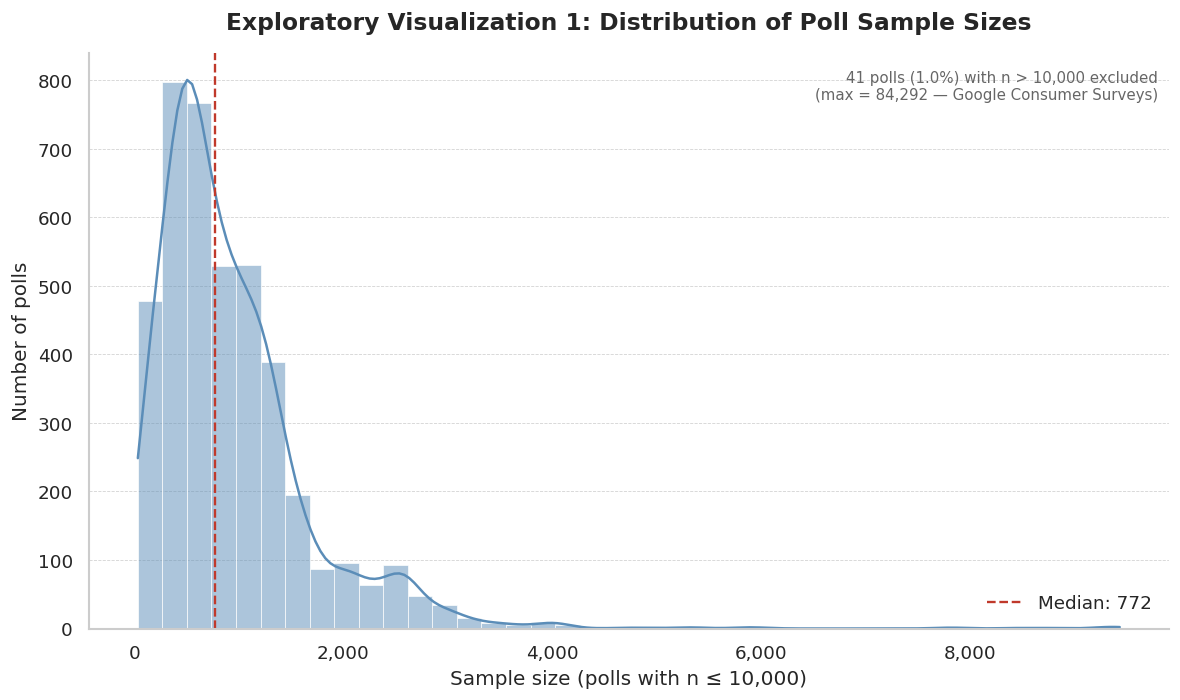

In [ ]:
# Viz 1: Distribution of Poll Sample Sizes

# Seuil pour les outliers (au-dessus = outlier)
OUTLIER_THRESHOLD = 10_000
n_outliers = (df_eda["samplesize"] > OUTLIER_THRESHOLD).sum()
pct_outliers = n_outliers / df_eda["samplesize"].notna().sum() * 100

df_plot = df_eda[df_eda["samplesize"] <= OUTLIER_THRESHOLD].copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_plot,
    x="samplesize",
    bins=40,
    kde=True,
    color="#5B8DB8",
    edgecolor="white",
    linewidth=0.4,
    ax=ax
)

# Ligne médiane
median_val = df_eda["samplesize"].median()
ax.axvline(median_val, color="#C0392B", linestyle="--", linewidth=1.4,
           label=f"Median: {int(median_val):,}")
ax.legend(fontsize=11, frameon=False)

# Titres & axes
ax.set_title(
    "Exploratory Visualization 1: Distribution of Poll Sample Sizes",
    fontsize=14, fontweight="bold", pad=14
)
ax.set_xlabel("Sample size (polls with n ≤ 10,000)", fontsize=12)
ax.set_ylabel("Number of polls", fontsize=12)

# Note outliers dans le sous-titre
ax.text(
    0.99, 0.97,
    f"{n_outliers} polls ({pct_outliers:.1f}%) with n > 10,000 excluded\n(max = 84,292 — Google Consumer Surveys)",
    transform=ax.transAxes,
    fontsize=9, color="#666666",
    ha="right", va="top"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="lightgrey", linewidth=0.5, linestyle="--")
ax.grid(axis="x", visible=False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("viz1_samplesize_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Dans cette première visualisation, je voulais comprendre la structure méthodologique de l'ensemble de données en analysant la taille des échantillons des sondages. Chaque barre représente le nombre de sondages correspondant à une certaine taille d'échantillon. La plupart des sondages se concentrent dans la tranche inférieure, tandis qu'un petit nombre d'entre eux présentent des échantillons très importants. Ces valeurs très élevées ayant tendance à étirer l'axe des abscisses et à rendre la distribution principale plus difficile à lire, j'ai exclu de la représentation les sondages comptant plus de 10 000 répondants, tout en les mentionnant dans les annotations.

**Comment l’écart entre Clinton et Trump évolue dans le temps, pour les sondages nationaux auprès des likely voters?**

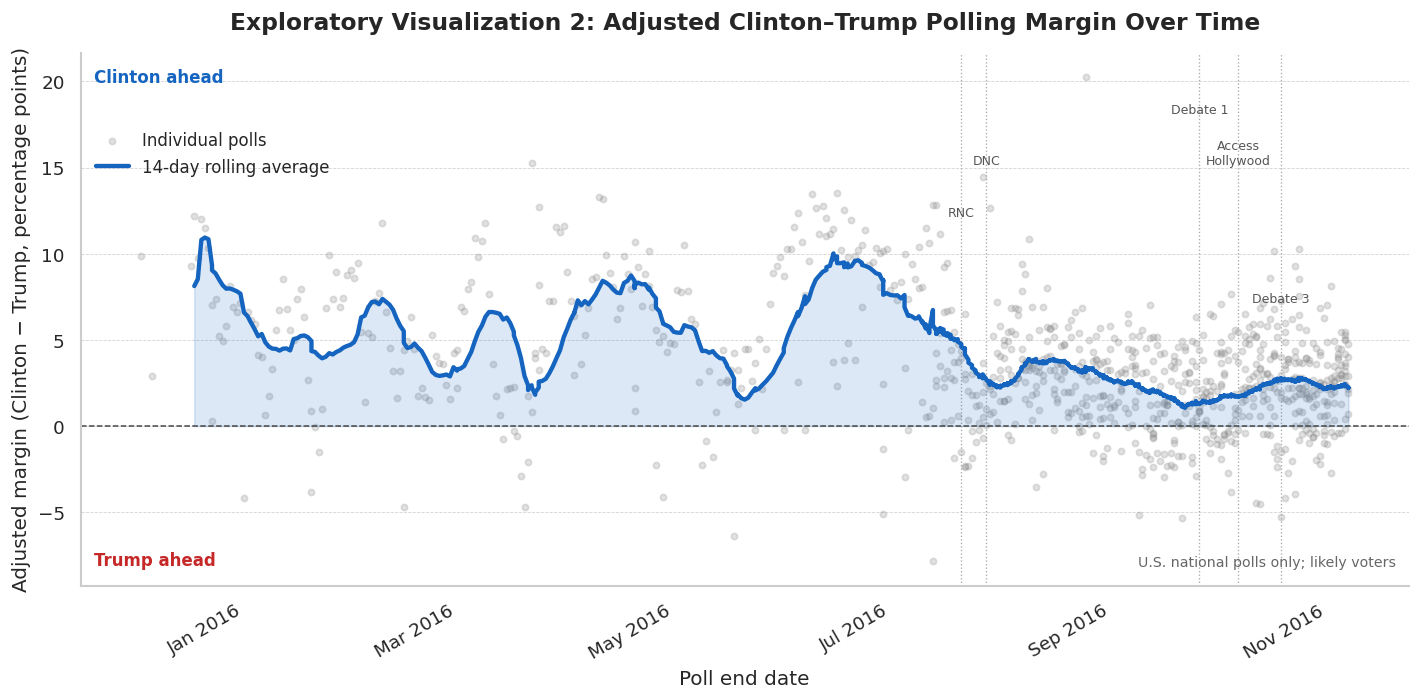

In [ ]:
# Viz 2: Adjusted Clinton–Trump Polling Margin Over Time

# Data: U.S. national polls, likely voters only

df_national = df_eda[
    (df_eda["state"] == "U.S.") &
    (df_eda["population"] == "lv")
].copy()

df_national = df_national.dropna(
    subset=["adj_margin_clinton_trump", "enddate"]
)

df_national = df_national.sort_values("enddate")

# 14-day rolling average
df_roll = df_national.set_index("enddate")

rolling = (
    df_roll["adj_margin_clinton_trump"]
    .rolling("14D", min_periods=3)
    .mean()
    .reset_index()
)

rolling.columns = ["enddate", "rolling_margin"]

# Figure

fig, ax = plt.subplots(figsize=(12, 6))

# Individual polls in the background
ax.scatter(
    df_national["enddate"],
    df_national["adj_margin_clinton_trump"],
    color="#8A8A8A",
    alpha=0.25,
    s=14,
    zorder=1,
    label="Individual polls"
)

# Shaded area above/below zero
ax.fill_between(
    rolling["enddate"],
    rolling["rolling_margin"],
    0,
    where=rolling["rolling_margin"] >= 0,
    color="#1565C0",
    alpha=0.15,
    zorder=2
)

ax.fill_between(
    rolling["enddate"],
    rolling["rolling_margin"],
    0,
    where=rolling["rolling_margin"] < 0,
    color="#C62828",
    alpha=0.15,
    zorder=2
)

# Main rolling average line
ax.plot(
    rolling["enddate"],
    rolling["rolling_margin"],
    color="#1565C0",
    linewidth=2.6,
    zorder=3,
    label="14-day rolling average"
)

# Zero reference line
ax.axhline(
    0,
    color="#444444",
    linewidth=0.9,
    linestyle="--",
    zorder=2
)

# Key campaign events
# Keep only a few events to avoid visual clutter.

events = [
    ("2016-07-21", "RNC", 12),
    ("2016-07-28", "DNC", 15),
    ("2016-09-26", "Debate 1", 18),
    ("2016-10-07", "Access\nHollywood", 15),
    ("2016-10-19", "Debate 3", 7),
]

for date_str, label, y_pos in events:
    xval = pd.Timestamp(date_str)
    if rolling["enddate"].min() <= xval <= rolling["enddate"].max():
        ax.axvline(
            xval,
            color="#AAAAAA",
            linewidth=0.8,
            linestyle=":",
            zorder=1
        )
        ax.text(
            xval,
            y_pos,
            label,
            fontsize=7.5,
            color="#555555",
            ha="center",
            va="bottom"
        )

# Direction labels

ax.text(
    0.01,
    0.97,
    "Clinton ahead",
    transform=ax.transAxes,
    fontsize=10,
    color="#1565C0",
    fontweight="bold",
    va="top"
)

ax.text(
    0.01,
    0.03,
    "Trump ahead",
    transform=ax.transAxes,
    fontsize=10,
    color="#C62828",
    fontweight="bold",
    va="bottom"
)

# Small methodological note
ax.text(
    0.99,
    0.03,
    "U.S. national polls only; likely voters",
    transform=ax.transAxes,
    fontsize=8.5,
    color="#666666",
    ha="right",
    va="bottom"
)

# Titles and axes

ax.set_title(
    "Exploratory Visualization 2: Adjusted Clinton–Trump Polling Margin Over Time",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Poll end date", fontsize=12)
ax.set_ylabel("Adjusted margin (Clinton − Trump, percentage points)", fontsize=12)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=30, ha="right")

# Legend
ax.legend(
    fontsize=10,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0, 0.88)
)

# Decluttering
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", color="lightgrey", linewidth=0.5, linestyle="--")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig("viz2_margin_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

Dans la deuxième visualisation, j'ai analysé l'évolution de l'écart ajusté entre Clinton et Trump dans les sondages. Cet écart est calculé en soustrayant le soutien ajusté de Trump au soutien ajusté de Clinton. Lorsque la ligne est au-dessus de zéro, Clinton est en tête ; lorsqu'elle est en dessous de zéro, c'est Trump qui est en tête. Les points gris représentent les sondages individuels, tandis que la ligne bleue indique une moyenne mobile sur 14 jours. J'ai opté pour la moyenne mobile car les sondages individuels peuvent être instables, et la courbe mobile permet de mieux visualiser la tendance générale.

***Est-ce que les résultats ajustés de Clinton sont proches des résultats bruts, ou est-ce que l’ajustement change beaucoup les valeurs ?***

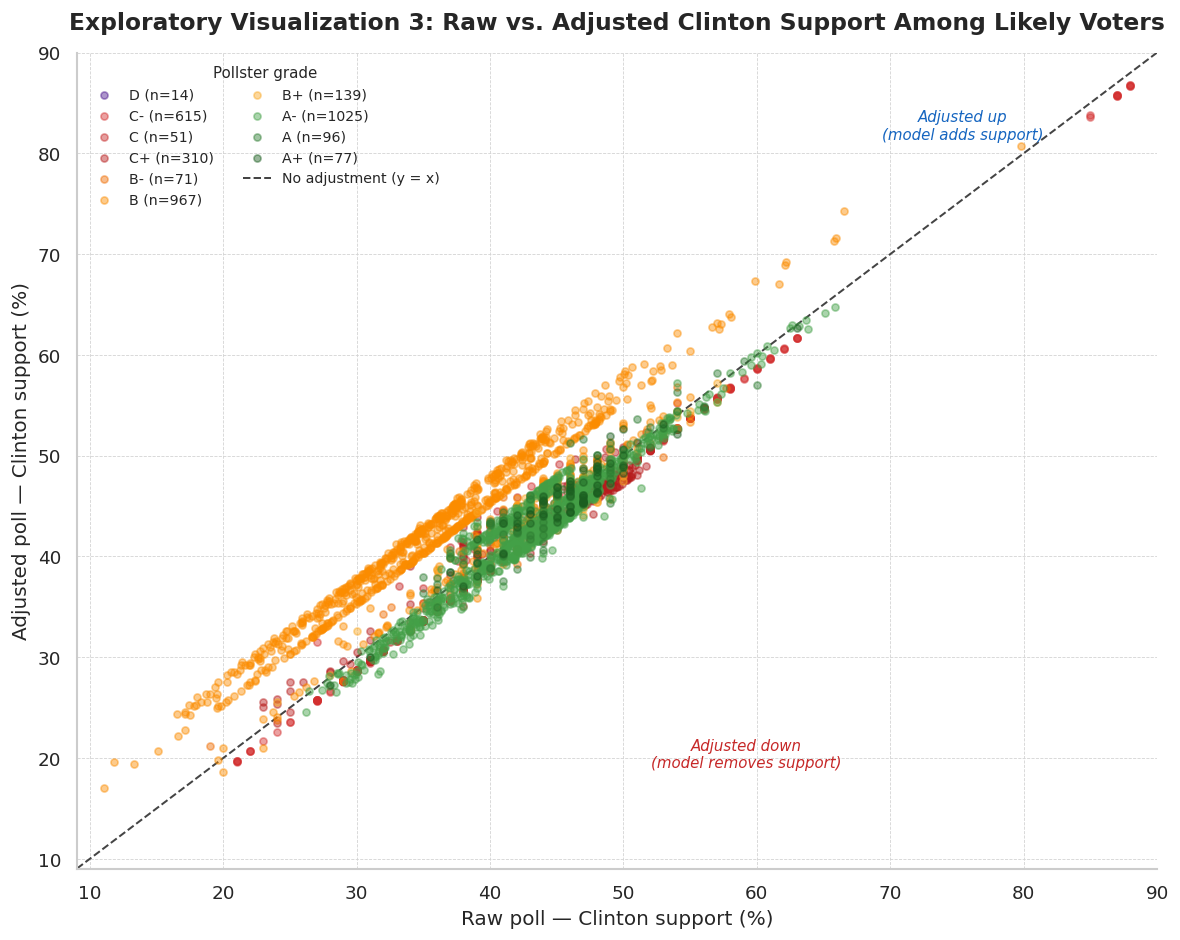

In [ ]:
# Viz 3: Raw vs. Adjusted Clinton Support Among Likely Voters

# Data: likely voters only, excluding missing pollster grades

df_scatter = df_eda[
    (df_eda["population"] == "lv") &
    (df_eda["grade"].notna())
].copy()

# Ordinal order for pollster grades
grade_order = ["A+", "A", "A-", "B+", "B", "B-", "C+", "C", "C-", "D"]

df_scatter["grade"] = pd.Categorical(
    df_scatter["grade"],
    categories=grade_order,
    ordered=True
)

df_scatter = df_scatter.dropna(
    subset=["rawpoll_clinton", "adjpoll_clinton", "grade"]
)

# Palette: stronger grades in green, middle grades in orange, lower grades in red/purple
palette = {
    "A+": "#1B5E20",
    "A":  "#2E7D32",
    "A-": "#43A047",
    "B+": "#F9A825",
    "B":  "#FB8C00",
    "B-": "#EF6C00",
    "C+": "#B71C1C",
    "C":  "#C62828",
    "C-": "#D32F2F",
    "D":  "#4A148C"
}

# Figure

fig, ax = plt.subplots(figsize=(10, 8))

# Plot points by grade
# Lower grades are drawn first, stronger grades later, so they remain visible.
for grade in reversed(grade_order):
    subset = df_scatter[df_scatter["grade"] == grade]

    if len(subset) == 0:
        continue

    ax.scatter(
        subset["rawpoll_clinton"],
        subset["adjpoll_clinton"],
        color=palette[grade],
        alpha=0.45,
        s=18,
        zorder=2,
        label=f"{grade} (n={len(subset)})"
    )

# Reference line: y = x

x_min = min(df_scatter["rawpoll_clinton"].min(), df_scatter["adjpoll_clinton"].min())
x_max = max(df_scatter["rawpoll_clinton"].max(), df_scatter["adjpoll_clinton"].max())

padding = 2
lims = [x_min - padding, x_max + padding]

ax.plot(
    lims,
    lims,
    color="#444444",
    linewidth=1.2,
    linestyle="--",
    zorder=1,
    label="No adjustment (y = x)"
)

ax.set_xlim(lims)
ax.set_ylim(lims)

# Zone annotations
# Above the line: adjusted value > raw value
# Below the line: adjusted value < raw value

ax.text(
    0.82,
    0.93,
    "Adjusted up\n(model adds support)",
    transform=ax.transAxes,
    fontsize=9,
    color="#1565C0",
    ha="center",
    va="top",
    style="italic"
)

ax.text(
    0.62,
    0.12,
    "Adjusted down\n(model removes support)",
    transform=ax.transAxes,
    fontsize=9,
    color="#C62828",
    ha="center",
    va="bottom",
    style="italic"
)

# Titles and labels

ax.set_title(
    "Exploratory Visualization 3: Raw vs. Adjusted Clinton Support Among Likely Voters",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Raw poll — Clinton support (%)", fontsize=12)
ax.set_ylabel("Adjusted poll — Clinton support (%)", fontsize=12)

# Legend

ax.legend(
    fontsize=8.5,
    frameon=False,
    ncol=2,
    loc="upper left",
    title="Pollster grade",
    title_fontsize=9
)

# Decluttering

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    color="lightgrey",
    linewidth=0.5,
    linestyle="--",
    zorder=0
)

plt.tight_layout()
plt.savefig("viz3_raw_vs_adj_by_grade.png", dpi=150, bbox_inches="tight")
plt.show()

Dans la troisième visualisation, j'ai comparé le soutien brut de Clinton dans les sondages avec son soutien ajusté auprès des électeurs probables. Chaque point représente un sondage. La ligne diagonale en pointillés indique le point où les valeurs brutes et ajustées seraient exactement égales. Si un point se situe sur la ligne, l'ajustement n'a pas eu d'incidence significative sur le soutien à Clinton. Si un point se situe au-dessus de la ligne, la valeur ajustée est supérieure à la valeur brute. Si un point se situe en dessous de la ligne, la valeur ajustée est inférieure à la valeur brute.

**Pour les résultats des sondages préliminaires, quel est le candidat entête des sondages pour chaque état ?**

In [ ]:
import plotly.graph_objects as go

# Viz 4: Map of Clinton-Trump raw polls per state - likely voters, excluding U.S National votes

df_map = df_eda[df_eda["population"] == "lv"].copy()

# Remove national polls
df_map = df_map[df_map["state"] != "U.S."]

#Group polling by state
state_polling = (
    df_map.groupby("state")[
        ["rawpoll_clinton", "rawpoll_trump"]
    ]
    .median()
    .reset_index()
)

# Function to determine winner and color intensity
def get_color_intensity(row):
    margin = row["rawpoll_clinton"] - row["rawpoll_trump"]
    abs_margin = abs(margin)

    if margin > 0: # Clinton leads
        if abs_margin < 5:
            return 0  # Clinton, (lead < 5)
        else:
            return 1  # Clinton (lead >= 5)
    elif margin < 0: # Trump leads
        if abs_margin < 5:
            return 2  # Trump (lead < 5)
        else:
            return 3  # Trump (lead >= 5)
    else: # Tie
        return 4

# Added column to keep track of winner and intensity
state_polling["intensity_category"] = state_polling.apply(get_color_intensity, axis=1)

# Map rows to their abbreviation
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT',
    'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME',
    'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI',
    'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM',
    'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND',
    'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
    'Pennsylvania': 'PA', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
}

state_polling["abbr"] = state_polling["state"].map(state_abbrev)

# Labels for the legend
state_polling["label"] = (
    "Raw polling" + "<br>" +
    "Clinton: " + state_polling["rawpoll_clinton"].round(1).astype(str) + "<br>" +
    "Trump: " + state_polling["rawpoll_trump"].round(1).astype(str) + "<br>"
)

# Use intensity_category for the 'z' value in choropleth
state_polling["z"] = state_polling["intensity_category"]

# Create the map
fig = go.Figure(data=go.Choropleth(
    locations=state_polling["abbr"],
    z=state_polling["z"],
    locationmode='USA-states',
    text=state_polling["label"],
    hoverinfo='text',
    colorscale=[
        [0/4, "#6baed6"], [0.0000000001/4, "#6baed6"], # Clinton, light blue (lead < 5)
        [1/4, "#1565C0"], [1.0000000001/4, "#1565C0"], # Clinton, dark blue (lead >= 5)
        [2/4, "#E57373"], [2.0000000001/4, "#E57373"], # Trump, light red (lead < 5)
        [3/4, "#C62828"], [3.0000000001/4, "#C62828"], # Trump, dark red (lead >= 5)
        [4/4, "white"], [1.0, "white"] # Tie/Even
    ],
    showscale=False,
    marker_line_color='white',
    marker_line_width=1,
    zmin=0,
    zmax=4,
))

# Grey for missing states
fig.update_geos(
    scope="usa",
    showcountries=False,
    showlakes=True,
    lakecolor="lightgrey",
    bgcolor="white"
)

# Create the legend with different entries for intensity levels
fig.add_trace(go.Scattergeo(
    lon=[None], lat=[None],
    mode='markers',
    marker=dict(size=10, color="#1565C0"),
    name='Clinton (Lead >= 5)'
))
fig.add_trace(go.Scattergeo(
    lon=[None], lat=[None],
    mode='markers',
    marker=dict(size=10, color="#6baed6"),
    name='Clinton (Lead < 5)'
))
fig.add_trace(go.Scattergeo(
    lon=[None], lat=[None],
    mode='markers',
    marker=dict(size=10, color="#C62828"),
    name='Trump (Lead >= 5)'
))
fig.add_trace(go.Scattergeo(
    lon=[None], lat=[None],
    mode='markers',
    marker=dict(size=10, color="#E57373"),
    name='Trump (Lead < 5)'
))
fig.add_trace(go.Scattergeo(
    lon=[None], lat=[None],
    mode='markers',
    marker=dict(size=10, color="lightgrey", line=dict(width=1, color="black")),
    name='Not included in polling'
))

fig.add_trace(go.Scattergeo(
    lon=[None], lat=[None],
    mode='markers',
    marker=dict(size=10, color="white", line=dict(width=1, color="black")),
    name='Tie/Even'
))

# Titles and Labels
fig.update_layout(
    title=dict(
        text="2016 US Election Raw Polling by State (Likely Voters Only)<br>",
        x=0.5,
        xanchor="center",
        font=dict(
            color="black",
            size=20
        )
    ),
    geo_scope='usa',
    legend=dict(
        title=dict(text="Candidate Lead", font=dict(color="black")),
        bgcolor="white",
        bordercolor="Black",
        borderwidth=1,
        font=dict(color="black")
    ),
    paper_bgcolor="white"
)

fig.write_html("Viz4_Map_Clinton-Trump_raw_polls.html")
fig.show()

Dans cette quatrième visualisation, on a évalué les résultats des sondages par états en se concentrant sur les likely voters. La couleur de chaque état correspond au candidat en tête des sondages selon la population likely voters. Il y a aussi une séparation en intensité lié à l'écart de pourcentage des votes entre le candidat en tête et le second. Si l'écart est plus grand ou égale à 5% alors la couleur est plus intense et si l'écart est plus petit que 5% alors la couleur est moins intense. On peut mettre la souris sur l'état pour voir les pourcentages exact pour chaque candidat.

**Quel est la distribution des votes dans les differentes populations ?**

/tmp/ipykernel_902/3866651026.py:53: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



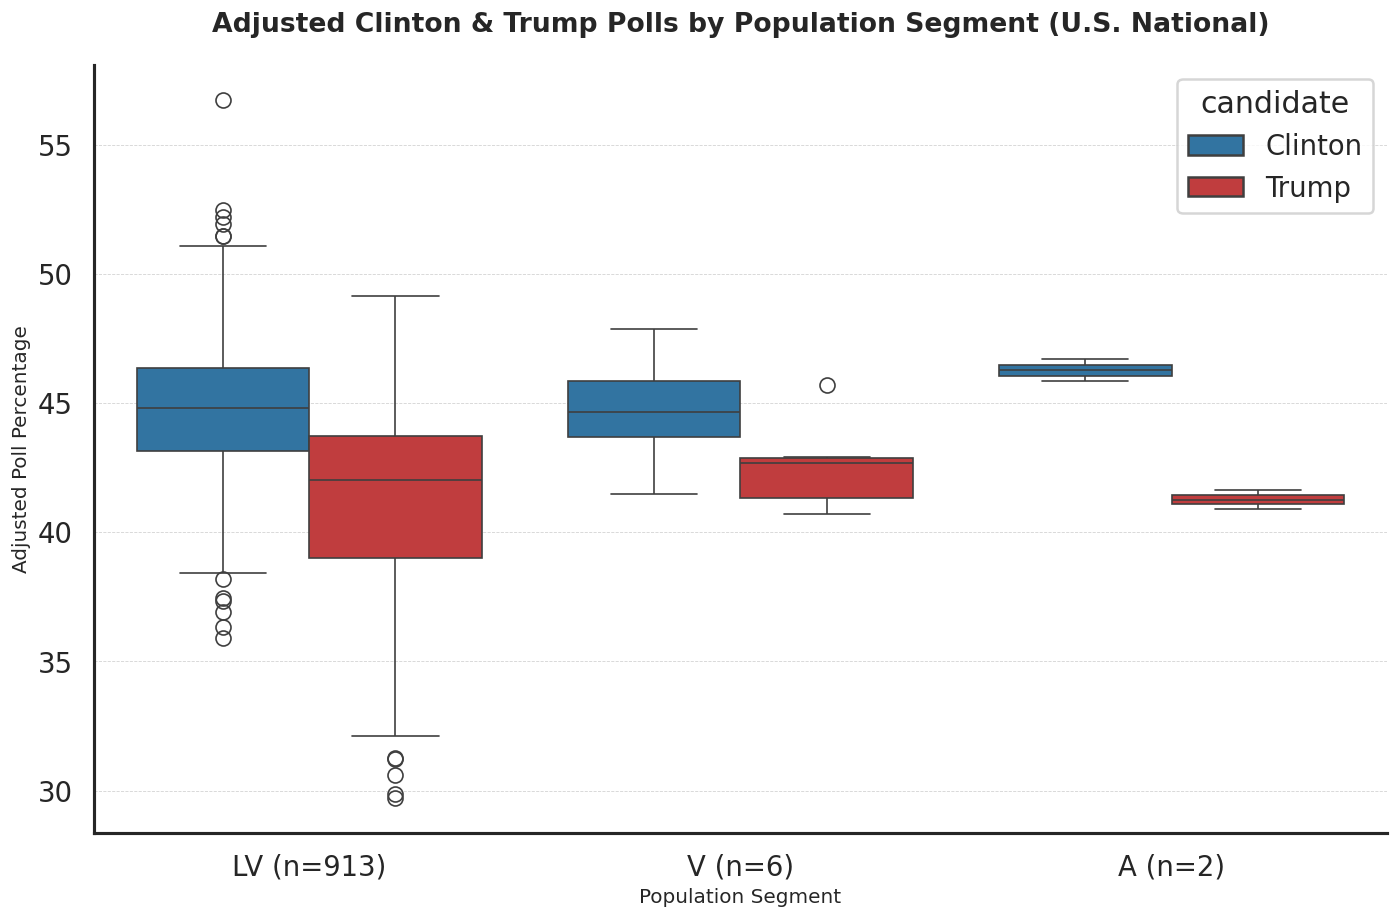

In [ ]:
#Viz 5: Percentages of votes per Population segment (lv, r , v, a) for U.S. National polls
df_hist_national = df_eda.copy()
df_hist_national = df_hist_national[df_hist_national["state"] == "U.S."]

# Define a palette for the population segments
candidate_palette = {
    "Clinton": "#1f77b4", # Blue
    "Trump": "#d62728"    # Red
}

fig, ax = plt.subplots(figsize=(12, 8))

# Filter for relevant population rows
population_segments_order = ["lv", "v", "a"]
df_filtered_national = df_hist_national[df_hist_national['population'].isin(population_segments_order)].copy()

# Combine Clinton and Trump adjusted polls into one column
df_melted_national = df_filtered_national.melt(
    id_vars=['population'],
    value_vars=['adjpoll_clinton', 'adjpoll_trump'],
    var_name='candidate',
    value_name='adjusted_poll'
)

# Legend
df_melted_national['candidate'] = df_melted_national['candidate'].map({
    'adjpoll_clinton': 'Clinton',
    'adjpoll_trump': 'Trump'
})
#Boxplot
sns.boxplot(
    data=df_melted_national,
    x="population",
    y="adjusted_poll",
    hue="candidate",
    palette=candidate_palette,
    order=population_segments_order,
    ax=ax
)

# Titles and labels
ax.set_title(
    "Adjusted Clinton & Trump Polls by Population Segment (U.S. National)",
    fontsize=16,
    fontweight="bold",
    pad=20
)
ax.set_xlabel("Population Segment", fontsize=12)
ax.set_ylabel("Adjusted Poll Percentage", fontsize=12)

# This counts unique polls per population segment in the filtered data
pop_counts = df_filtered_national['population'].value_counts().reindex(population_segments_order)
ax.set_xticklabels([f"{p.upper()} (n={pop_counts.get(p, 0)})" for p in population_segments_order])

ax.grid(axis="y", color="lightgrey", linewidth=0.5, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("viz5_adjusted_clinton_trump_polls_by_population.png", dpi=150, bbox_inches="tight")
plt.show()

Dans cette cinquième visualisation, on a évalué la distribution des votes ajustés de Clinton vs Trump par population incluant likely voters, voters et adult. Le nombre de pollsters évaluant cette tranche de population est écrit entre parenthèse.

**Quel sont les différences des ajustements par états ?**

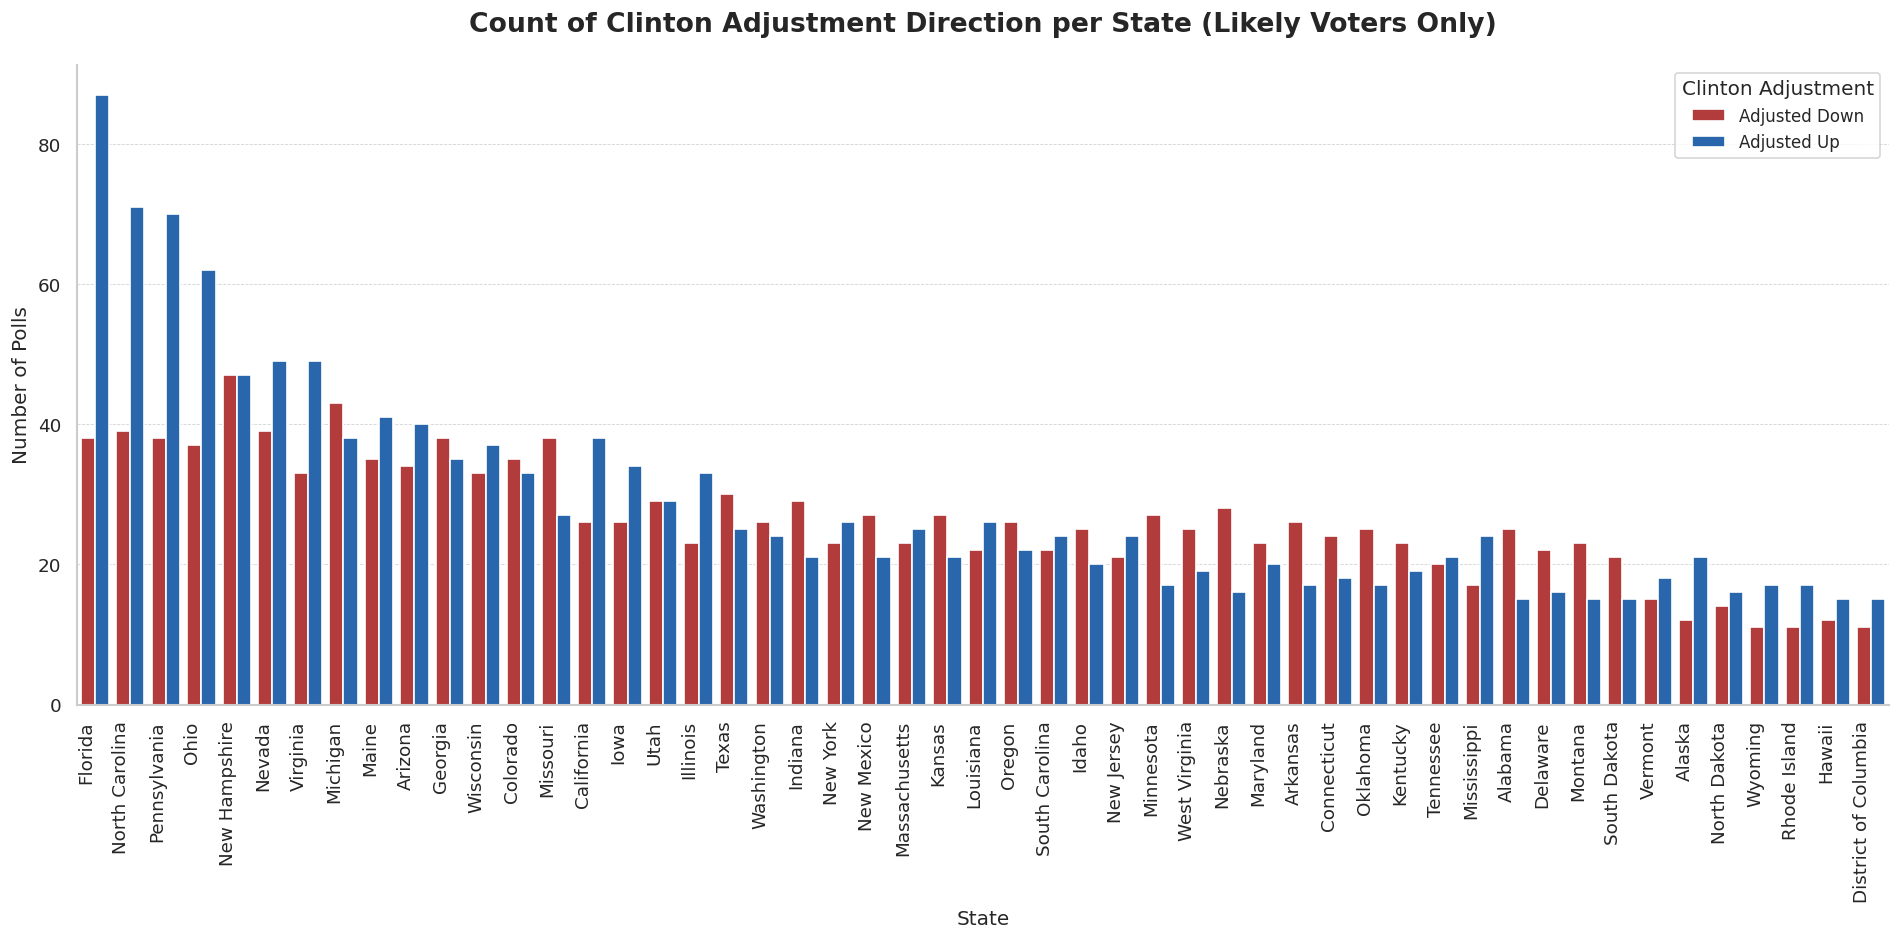

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Viz 6: Count of Clinton Adjustment Direction per State (Likely Voters Only)

# Raw vs adjusted per state
# For population likely voters
df_margin = df_eda.copy()
df_margin = df_margin[df_margin["state"] != "U.S."]
df_margin = df_margin[df_margin["population"] == "lv"]

# Combine Nebraska CD-1, CD-2 et CD-3
nebraska_cds = ['Nebraska CD-1', 'Nebraska CD-2', 'Nebraska CD-3']
df_margin.loc[df_margin['state'].isin(nebraska_cds), 'state'] = 'Nebraska'

# Combine Main CD-1 et CD-2
maine_cds = ['Maine CD-1', 'Maine CD-2']
df_margin.loc[df_margin['state'].isin(maine_cds), 'state'] = 'Maine'

df_margin["margin_clinton"] = df_margin["rawpoll_clinton"] - df_margin["adjpoll_clinton"]
df_margin["margin_trump"] = df_margin["rawpoll_trump"] - df_margin["adjpoll_trump"]

# Added column for Clinton's adjustment direction
def get_adjustment_direction(margin):
    if margin > 0:  # rawpoll_clinton > adjpoll_clinton, meaning adjusted down
        return "Adjusted Down"
    elif margin < -0: # rawpoll_clinton < adjpoll_clinton, meaning adjusted up
        return "Adjusted Up"
    else: # Close to zero means no significant change
        return "No Significant Change"

df_margin["clinton_adjustment_direction"] = df_margin["margin_clinton"].apply(get_adjustment_direction)

# Plot Clinton adjustment direction per state
fig, ax = plt.subplots(figsize=(16, 8))

sns.countplot(
    data=df_margin,
    x="state",
    hue="clinton_adjustment_direction",
    palette={"Adjusted Up": "#1565C0", "Adjusted Down": "#C62828", "No Significant Change": "#8A8A8A"},
    ax=ax,
    order=df_margin["state"].value_counts().index # Order states by frequency of polls
)

# Titles and labels
ax.set_title(
    "Count of Clinton Adjustment Direction per State (Likely Voters Only)",
    fontsize=16,
    fontweight="bold",
    pad=20
)
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Number of Polls", fontsize=12)

plt.xticks(rotation=90, ha='right')
ax.legend(title="Clinton Adjustment", fontsize=10, title_fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="lightgrey", linewidth=0.5, linestyle="--")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig("viz6_clinton_adjustment_direction_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

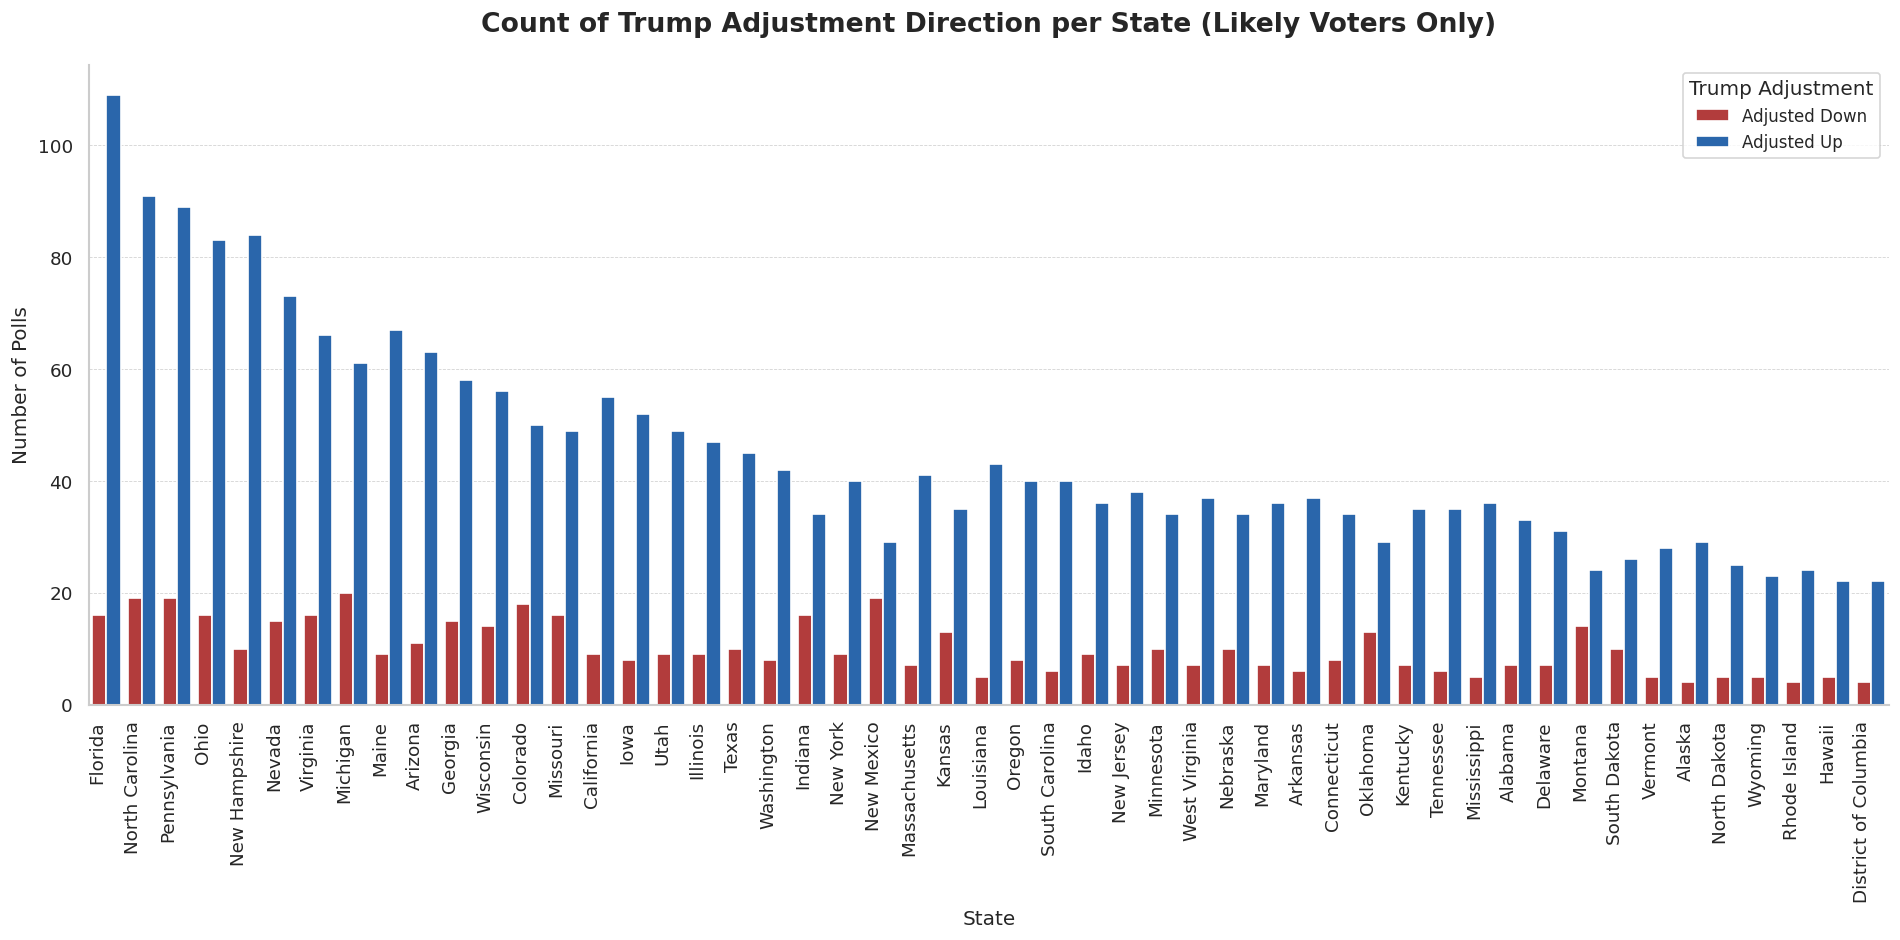

In [ ]:
#Plot Trump adjustment direction per state

df_margin["trump_adjustment_direction"] = df_margin["margin_trump"].apply(get_adjustment_direction)
fig, ax = plt.subplots(figsize=(16, 8))

sns.countplot(
    data=df_margin,
    x="state",
    hue="trump_adjustment_direction",
    palette={"Adjusted Up": "#1565C0", "Adjusted Down": "#C62828", "No Significant Change": "#8A8A8A"},
    ax=ax,
    order=df_margin["state"].value_counts().index # Order states by frequency of polls
)

# Titles and labels
ax.set_title(
    "Count of Trump Adjustment Direction per State (Likely Voters Only)",
    fontsize=16,
    fontweight="bold",
    pad=20
)
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Number of Polls", fontsize=12)

plt.xticks(rotation=90, ha='right')
ax.legend(title="Trump Adjustment", fontsize=10, title_fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="lightgrey", linewidth=0.5, linestyle="--")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig("viz6_trump_adjustment_direction_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

Dans cette sixième visualisation, on évalue l'écart entre les résultats brutes des polls et les résultats ajustés pour chaque états pour Clinton et Trump. La visualisation montre le nombre de pollsters qui ont ajusté le résultat en le diminuant (en rouge) ou en l'augmentant (en bleu). Ces résultats sont pris de la tranche de population likely voters.

# Task 3 : Definitive Visualizations

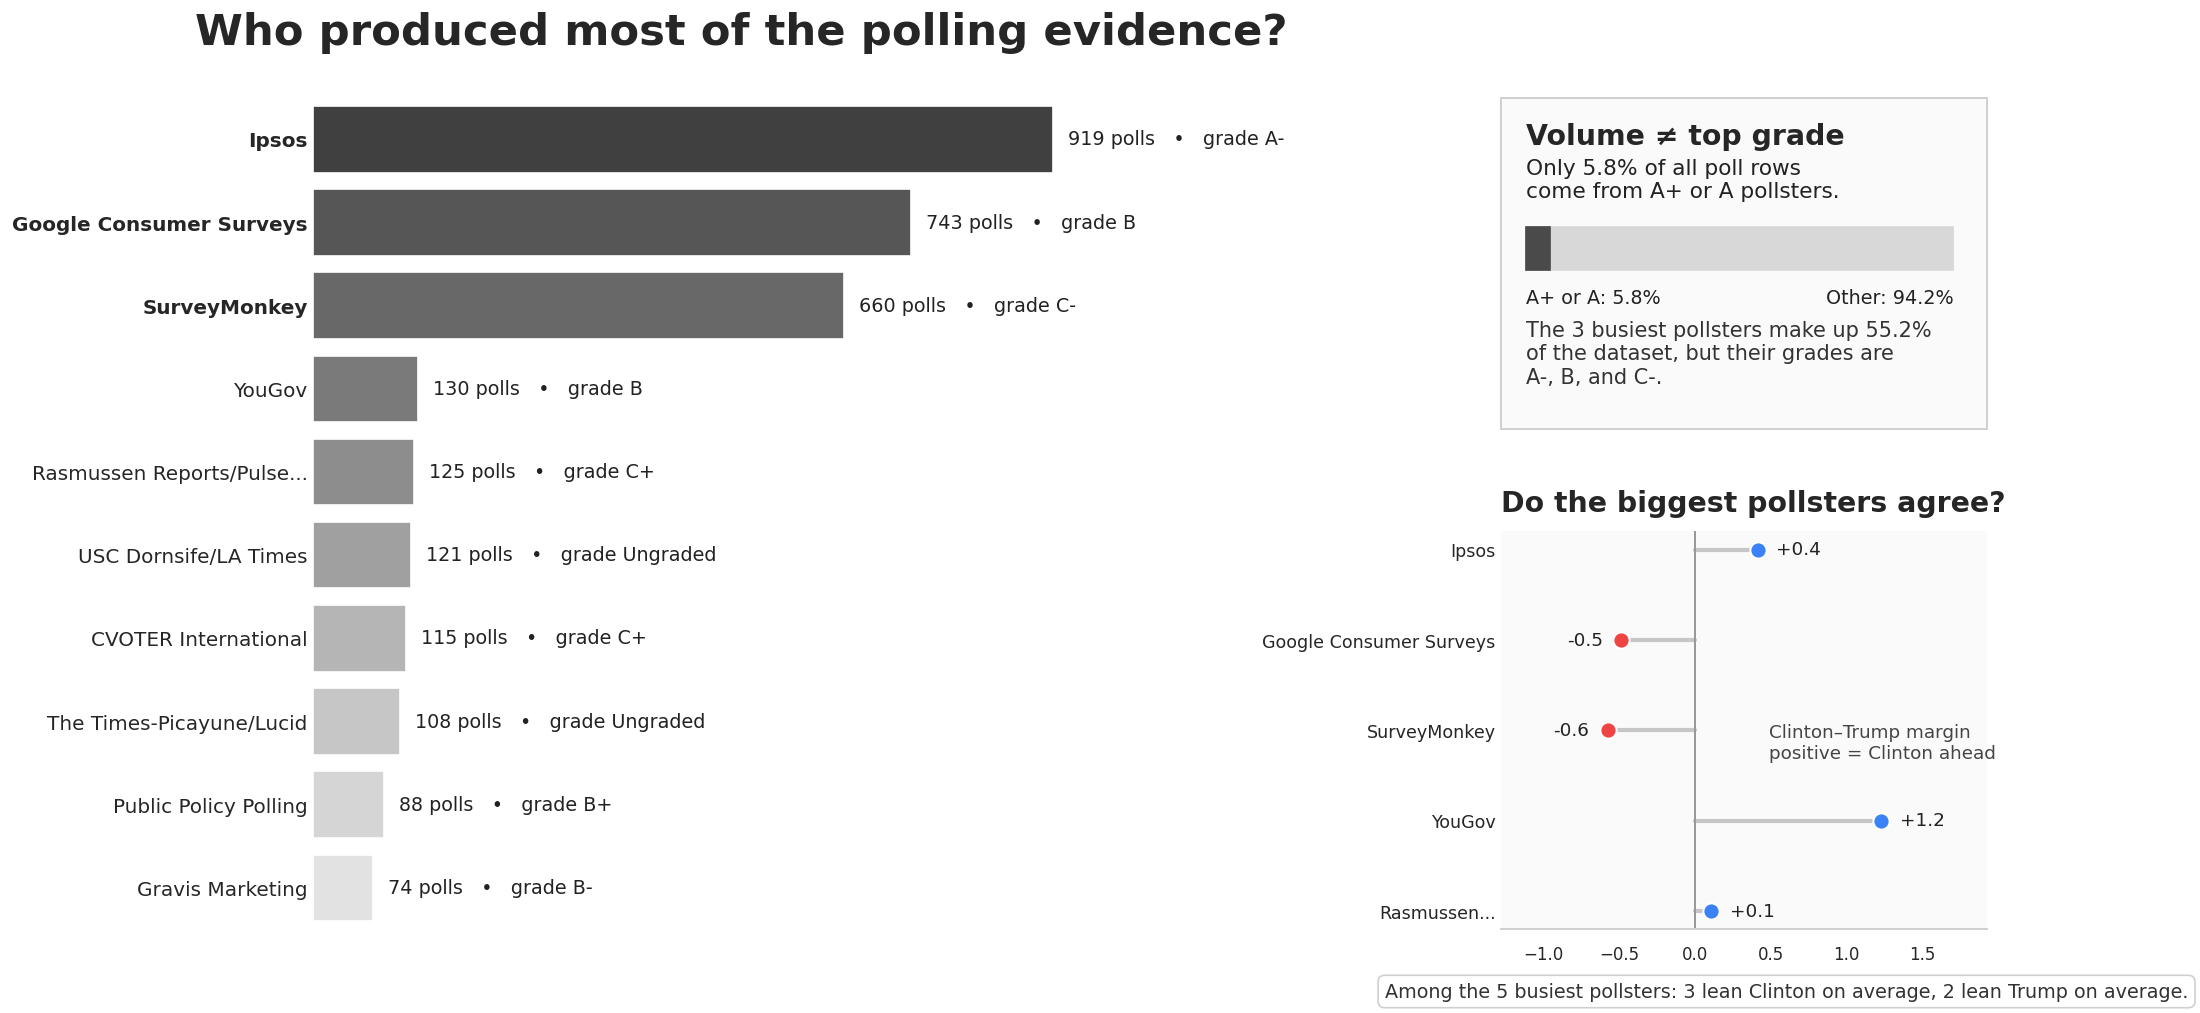

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import io
from matplotlib.patches import Rectangle

# ============================================================
# 1. LOAD DATA
# ============================================================

# If using Google Colab upload:
# from google.colab import files
# uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# If your file is already saved in Colab, use this instead:
# df = pd.read_csv("polls_us_election_2016 (1).csv")

df["grade_clean"] = df["grade"].fillna("Ungraded")
df["adj_margin"] = df["adjpoll_clinton"] - df["adjpoll_trump"]


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def main_grade(series):
    mode = series.mode()
    return mode.iloc[0] if len(mode) else "Ungraded"


def short_name(name, width=28):
    return textwrap.shorten(name, width=width, placeholder="...")


def lean_label(margin):
    if margin > 0:
        return "Clinton-leaning"
    elif margin < 0:
        return "Trump-leaning"
    return "Tied"


# ============================================================
# 3. SUMMARIZE POLLSTERS
# ============================================================

pollster_summary = (
    df.groupby("pollster")
      .agg(
          poll_count=("pollster", "size"),
          main_grade=("grade_clean", main_grade),
          mean_adj_margin=("adj_margin", "mean")
      )
      .sort_values("poll_count", ascending=False)
      .reset_index()
)

top_n = 10
top = pollster_summary.head(top_n).copy()
top = top.sort_values("poll_count", ascending=False)
top["short_pollster"] = top["pollster"].apply(lambda x: short_name(x, 30))

# Top 5 for mini candidate-margin panel
top5_margin = pollster_summary.head(5).copy()
top5_margin["short_pollster"] = top5_margin["pollster"].apply(lambda x: short_name(x, 24))
top5_margin["lean"] = top5_margin["mean_adj_margin"].apply(lean_label)

# Key facts
total_rows = len(df)

a_plus_count = (df["grade_clean"] == "A+").sum()
a_count = (df["grade_clean"] == "A").sum()
a_plus_a_count = a_plus_count + a_count
a_plus_a_share = 100 * a_plus_a_count / total_rows
other_share = 100 - a_plus_a_share

top3 = pollster_summary.head(3).copy()
top3_share = 100 * top3["poll_count"].sum() / total_rows

top5_clinton = (top5_margin["mean_adj_margin"] > 0).sum()
top5_trump = (top5_margin["mean_adj_margin"] < 0).sum()


# ============================================================
# 4. STYLE
# ============================================================

sns.set_theme(style="white", font_scale=1.05)

# Bars = shades of gray, darkest for biggest pollsters
gray_palette = sns.color_palette("Greys_r", n_colors=len(top) + 4)[2:len(top) + 2]

lean_colors = {
    "Clinton-leaning": "#3B82F6",
    "Trump-leaning": "#EF4444",
    "Tied": "#777777"
}


# ============================================================
# 5. FIGURE LAYOUT
# ============================================================

fig = plt.figure(figsize=(18, 9), facecolor="white")

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[2.7, 1.25],
    height_ratios=[1, 1.2],
    wspace=0.18,
    hspace=0.28
)

ax_main = fig.add_subplot(gs[:, 0])
ax_quality = fig.add_subplot(gs[0, 1])
ax_margin = fig.add_subplot(gs[1, 1])

# ============================================================
# MOVE "Volume ≠ top grade" BOX
# ============================================================
# Increase LEFT_SHIFT to move it more left.
# Increase UP_SHIFT to move it more up.

QUALITY_BOX_LEFT_SHIFT = 0.05
QUALITY_BOX_UP_SHIFT = 15.50

pos = ax_quality.get_position()

ax_quality.set_position([
    pos.x0 - QUALITY_BOX_LEFT_SHIFT,
    pos.y0 + QUALITY_BOX_UP_SHIFT,
    pos.width,
    pos.height
])

fig.suptitle(
    "Who produced most of the polling evidence?",
    fontsize=26,
    fontweight="bold",
    x=0.07,
    y=0.96,
    ha="left"
)


# ============================================================
# 6. MAIN BAR CHART
# ============================================================

sns.barplot(
    data=top,
    x="poll_count",
    y="short_pollster",
    order=top["short_pollster"],
    palette=gray_palette,
    ax=ax_main
)

ax_main.set_xlabel("")
ax_main.set_ylabel("")
ax_main.grid(False)
ax_main.tick_params(axis="x", bottom=False, labelbottom=False)
ax_main.tick_params(axis="y", length=0, labelsize=12)
sns.despine(ax=ax_main, left=True, bottom=True)

xmax = top["poll_count"].max()
ax_main.set_xlim(0, xmax * 1.42)

for i, row in enumerate(top.itertuples()):
    ax_main.text(
        row.poll_count + xmax * 0.02,
        i,
        f"{row.poll_count} polls   •   grade {row.main_grade}",
        va="center",
        fontsize=11.5,
        color="#222222"
    )

# Bold top 3 names
top3_pollsters = set(top3["pollster"])

for tick_label, row in zip(ax_main.get_yticklabels(), top.itertuples()):
    if row.pollster in top3_pollsters:
        tick_label.set_fontweight("bold")


# ============================================================
# 7. RIGHT PANEL 1 — QUALITY / GRADE CONTEXT
# ============================================================

ax_quality.set_facecolor("#FAFAFA")

for spine in ax_quality.spines.values():
    spine.set_visible(True)
    spine.set_color("#D0D0D0")
    spine.set_linewidth(1.2)

ax_quality.set_xticks([])
ax_quality.set_yticks([])
ax_quality.set_xlim(0, 1)
ax_quality.set_ylim(0, 1)

ax_quality.text(
    0.05,
    0.86,
    "Volume ≠ top grade",
    fontsize=17,
    fontweight="bold"
)

ax_quality.text(
    0.05,
    0.70,
    f"Only {a_plus_a_share:.1f}% of all poll rows\n"
    f"come from A+ or A pollsters.",
    fontsize=13,
    color="#222222"
)

# Share bar
bar_x = 0.05
bar_y = 0.48
bar_w = 0.88
bar_h = 0.13

ax_quality.add_patch(
    Rectangle(
        (bar_x, bar_y),
        bar_w,
        bar_h,
        color="#D8D8D8",
        transform=ax_quality.transAxes
    )
)

ax_quality.add_patch(
    Rectangle(
        (bar_x, bar_y),
        bar_w * (a_plus_a_share / 100),
        bar_h,
        color="#4A4A4A",
        transform=ax_quality.transAxes
    )
)

ax_quality.text(
    bar_x,
    bar_y - 0.10,
    f"A+ or A: {a_plus_a_share:.1f}%",
    fontsize=11.5,
    color="#222222"
)

ax_quality.text(
    bar_x + bar_w,
    bar_y - 0.10,
    f"Other: {other_share:.1f}%",
    fontsize=11.5,
    color="#222222",
    ha="right"
)

ax_quality.text(
    0.05,
    0.14,
    f"The 3 busiest pollsters make up {top3_share:.1f}%\n"
    f"of the dataset, but their grades are\n"
    f"A-, B, and C-.",
    fontsize=12.5,
    color="#333333"
)


# ============================================================
# 8. RIGHT PANEL 2 — CANDIDATE-RELATED MINI CHART
# ============================================================

ax_margin.set_facecolor("#FAFAFA")

for spine in ax_margin.spines.values():
    spine.set_visible(True)
    spine.set_color("#D0D0D0")
    spine.set_linewidth(1.2)

# Sort visually from most polls at the top to fewer polls at the bottom.
# Because matplotlib puts y=0 at the bottom, we sort ascending here.
mini = top5_margin.sort_values("poll_count", ascending=True).copy()

ax_margin.axvline(0, color="#999999", linewidth=1.2)

for i, row in enumerate(mini.itertuples()):
    color = lean_colors[row.lean]

    ax_margin.plot(
        [0, row.mean_adj_margin],
        [i, i],
        color="#C6C6C6",
        linewidth=2.5,
        zorder=1
    )

    ax_margin.scatter(
        row.mean_adj_margin,
        i,
        s=95,
        color=color,
        edgecolor="white",
        linewidth=1.2,
        zorder=3
    )

    ax_margin.text(
        row.mean_adj_margin + (0.12 if row.mean_adj_margin >= 0 else -0.12),
        i,
        f"{row.mean_adj_margin:+.1f}",
        va="center",
        ha="left" if row.mean_adj_margin >= 0 else "right",
        fontsize=11,
        color="#222222"
    )

ax_margin.set_title(
    "Do the biggest pollsters agree?",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=12
)

ax_margin.text(
    0.55,
    0.42,
    "Clinton–Trump margin\npositive = Clinton ahead",
    transform=ax_margin.transAxes,
    fontsize=11,
    color="#444444",
    va="bottom"
)

ax_margin.set_yticks(range(len(mini)))
ax_margin.set_yticklabels(mini["short_pollster"], fontsize=10.5)
ax_margin.tick_params(axis="y", length=0)
ax_margin.tick_params(axis="x", labelsize=10)

ax_margin.set_xlabel("")
ax_margin.set_ylabel("")
ax_margin.grid(False)

# More room for labels
xmin = mini["mean_adj_margin"].min()
xmax_margin = mini["mean_adj_margin"].max()
ax_margin.set_xlim(xmin - 0.7, xmax_margin + 0.7)

sns.despine(ax=ax_margin, left=True, bottom=False)

# Small insight under the mini chart
ax_margin.text(
    -0.24,
    -0.17,
    f"Among the 5 busiest pollsters: {top5_clinton} lean Clinton on average, "
    f"{top5_trump} lean Trump on average.",
    transform=ax_margin.transAxes,
    fontsize=11.5,
    color="#333333",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#D0D0D0"
    )
)


# ============================================================
# 9. SAVE / DISPLAY
# ============================================================

plt.subplots_adjust(top=0.88)

plt.savefig(
    "pollster_intro_graph_cleaner_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/final_population_mix_graph'

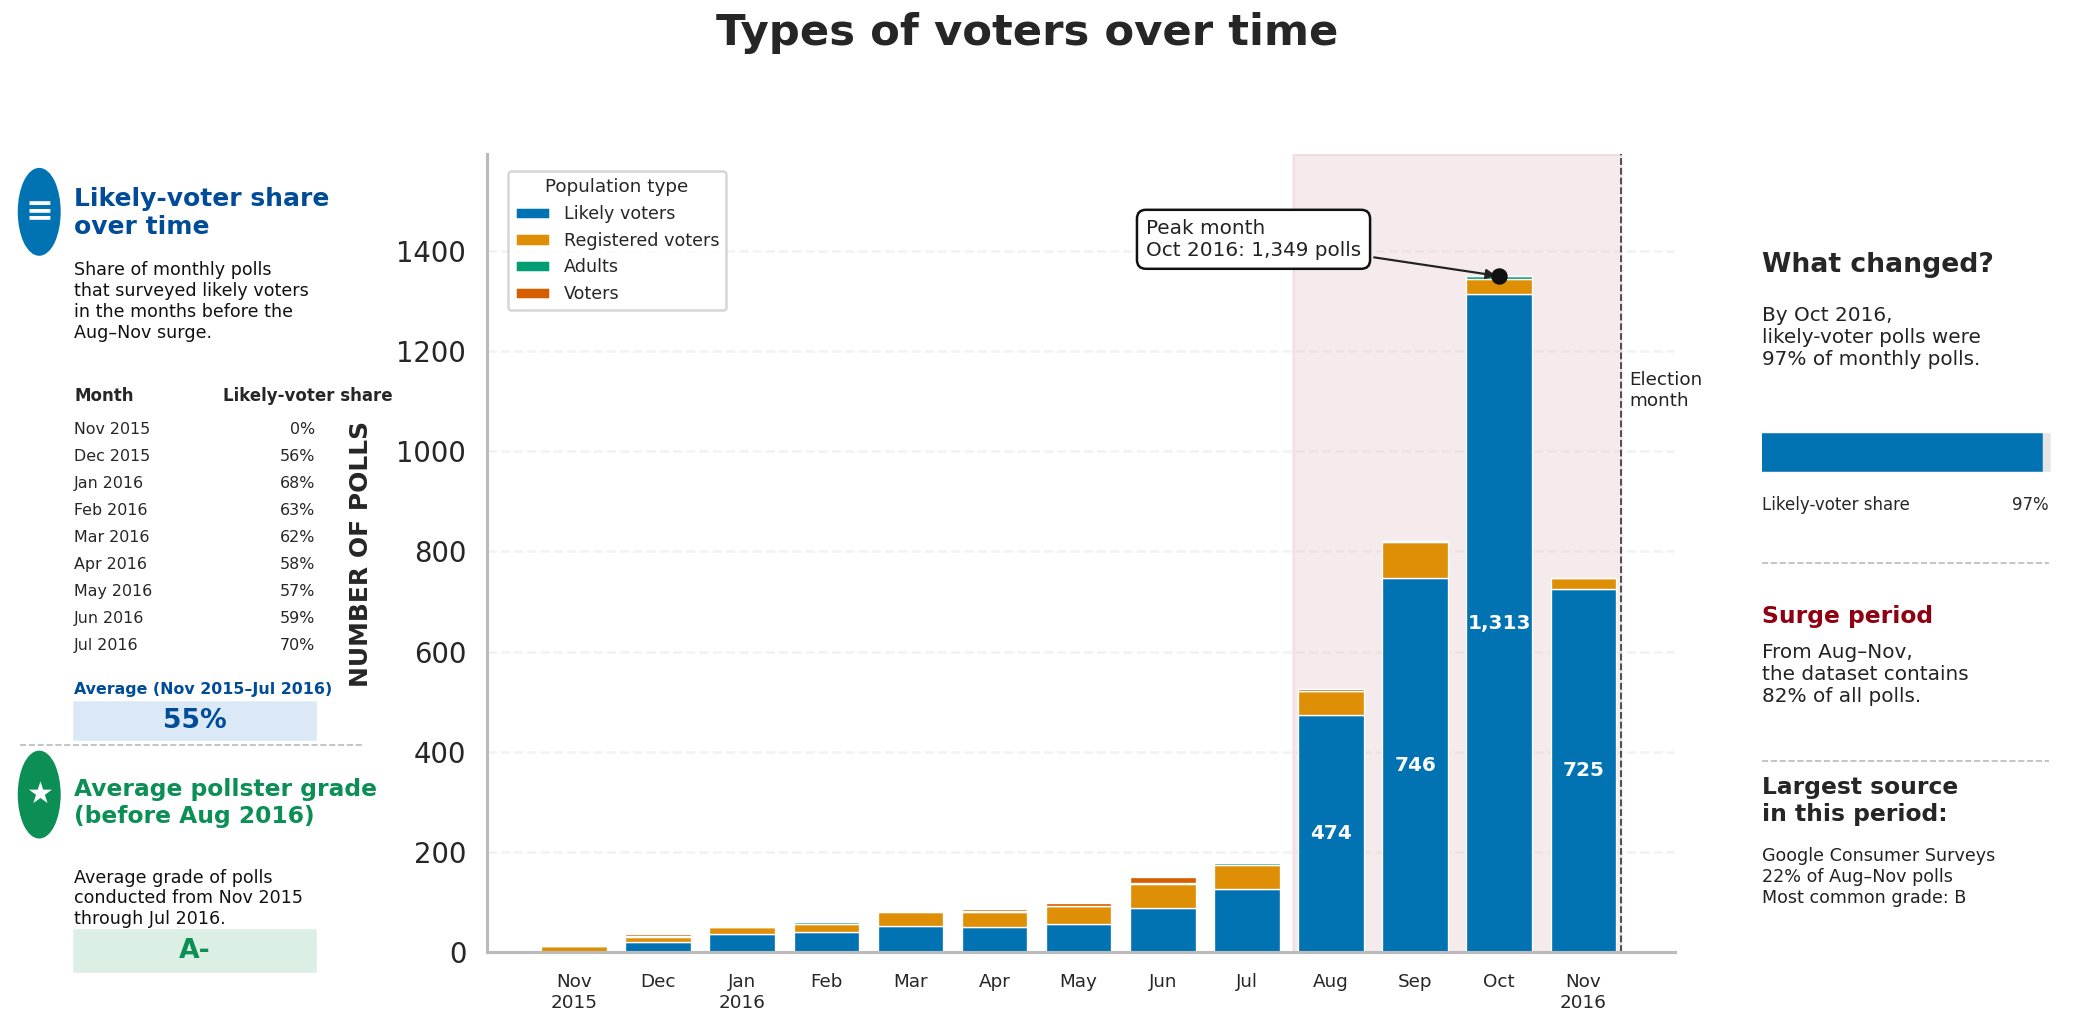

In [ ]:
import io
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, Circle, Patch

# =============================
# Load data - Google Colab
# =============================
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# =============================
# Clean data
# =============================
df["enddate"] = pd.to_datetime(df["enddate"], errors="coerce")
df["month"] = df["enddate"].dt.to_period("M").dt.to_timestamp()

pop_labels = {
    "lv": "Likely voters",
    "rv": "Registered voters",
    "a": "Adults",
    "v": "Voters"
}

df["population_label"] = df["population"].map(pop_labels).fillna(df["population"])

plot_df = df.dropna(subset=["month", "population_label"]).copy()

monthly_counts = (
    plot_df.groupby(["month", "population_label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

order = ["Likely voters", "Registered voters", "Adults", "Voters"]
monthly_counts = monthly_counts.reindex(columns=[c for c in order if c in monthly_counts.columns], fill_value=0)

monthly_total = monthly_counts.sum(axis=1)

if "Likely voters" in monthly_counts.columns:
    likely_share = (monthly_counts["Likely voters"] / monthly_total * 100).fillna(0)
else:
    likely_share = pd.Series(0, index=monthly_counts.index)

# =============================
# Key stats
# =============================
surge_start = pd.Timestamp("2016-08-01")
surge_end = pd.Timestamp("2016-11-01")

surge_df = plot_df[(plot_df["month"] >= surge_start) & (plot_df["month"] <= surge_end)]
pre_surge_df = plot_df[plot_df["month"] < surge_start]

surge_total = len(surge_df)
all_total = len(plot_df)
surge_share = 100 * surge_total / all_total if all_total > 0 else 0

if "pollster" in surge_df.columns and not surge_df["pollster"].dropna().empty:
    top_surge_pollster = surge_df["pollster"].dropna().value_counts().idxmax()
    top_surge_pollster_share = 100 * surge_df["pollster"].dropna().value_counts().iloc[0] / len(surge_df)
else:
    top_surge_pollster = "Unknown"
    top_surge_pollster_share = 0

grade_col = None
for col in ["grade_clean", "grade", "fte_grade"]:
    if col in df.columns:
        grade_col = col
        break

if grade_col is not None and not surge_df[grade_col].dropna().empty:
    top_surge_grade = surge_df[grade_col].dropna().value_counts().idxmax()
else:
    top_surge_grade = "Unknown"

if grade_col is not None and not pre_surge_df[grade_col].dropna().empty:
    common_pre_grade = pre_surge_df[grade_col].dropna().value_counts().idxmax()
else:
    common_pre_grade = "Unknown"

peak_month = monthly_total.idxmax()
peak_total = int(monthly_total.loc[peak_month])
peak_idx = list(monthly_counts.index).index(peak_month)

oct_2016 = pd.Timestamp("2016-10-01")
final_focus_month = oct_2016 if oct_2016 in monthly_total.index else monthly_total.index.max()
final_focus_share = likely_share.loc[final_focus_month]

pre_surge_months = likely_share[likely_share.index < surge_start]
pre_surge_avg = pre_surge_months.mean()

# =============================
# Seaborn style
# =============================
sns.set_theme(style="white", context="talk")

palette = sns.color_palette("colorblind", 4)

colors = {
    "Likely voters": palette[0],
    "Registered voters": palette[1],
    "Adults": palette[2],
    "Voters": palette[3],
}

accent = "#8f0010"
blue = colors["Likely voters"]
green = "#0b8f55"

# =============================
# Figure layout
# =============================
fig = plt.figure(figsize=(18, 9.5), facecolor="white")

ax_left = fig.add_axes([0.03, 0.12, 0.18, 0.72])
ax = fig.add_axes([0.25, 0.14, 0.55, 0.70])
ax_note = fig.add_axes([0.84, 0.18, 0.14, 0.58])

ax_left.axis("off")
ax_note.axis("off")

# =============================
# Main chart
# =============================
x = np.arange(len(monthly_counts.index))
bottom = np.zeros(len(monthly_counts))

surge_start_idx = list(monthly_counts.index).index(surge_start)
surge_end_idx = list(monthly_counts.index).index(surge_end)

ax.axvspan(
    surge_start_idx - 0.45,
    surge_end_idx + 0.45,
    color=accent,
    alpha=0.08,
    zorder=0
)

for col in monthly_counts.columns:
    ax.bar(
        x,
        monthly_counts[col].values,
        bottom=bottom,
        width=0.78,
        color=colors.get(col, "#999999"),
        edgecolor="white",
        linewidth=0.8,
        label=col,
        zorder=2
    )
    bottom += monthly_counts[col].values

ymax = monthly_total.max()

# Numbers inside large likely-voter bars
for i, month in enumerate(monthly_counts.index):
    if "Likely voters" in monthly_counts.columns:
        lv_count = monthly_counts.loc[month, "Likely voters"]
        if lv_count >= 400:
            ax.text(
                i,
                lv_count / 2,
                f"{int(lv_count):,}",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color="white"
            )

ax.scatter([peak_idx], [peak_total], s=70, color="#111111", zorder=5)

ax.annotate(
    f"Peak month\nOct 2016: {peak_total:,} polls",
    xy=(peak_idx, peak_total),
    xytext=(peak_idx - 4.2, peak_total * 1.03),
    arrowprops=dict(arrowstyle="-|>", color="#222222", lw=1.3),
    fontsize=12,
    color="#222222",
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#111111")
)

nov_2016 = pd.Timestamp("2016-11-01")
if nov_2016 in monthly_counts.index:
    nov_idx = list(monthly_counts.index).index(nov_2016)
    ax.axvline(nov_idx + 0.45, color="#444444", linestyle="--", linewidth=1.1)
    ax.text(
        nov_idx + 0.55,
        ymax * 0.86,
        "Election\nmonth",
        fontsize=11,
        color="#222222",
        va="top"
    )

month_labels = []
for m in monthly_counts.index:
    if m == pd.Timestamp("2015-11-01"):
        month_labels.append("Nov\n2015")
    elif m == pd.Timestamp("2016-01-01"):
        month_labels.append("Jan\n2016")
    elif m == pd.Timestamp("2016-11-01"):
        month_labels.append("Nov\n2016")
    else:
        month_labels.append(m.strftime("%b"))

ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=11)

ax.set_ylabel(
    "NUMBER OF POLLS",
    fontsize=15,
    fontweight="bold",
    labelpad=14
)

ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

ax.spines["left"].set_color("#BBBBBB")
ax.spines["bottom"].set_color("#BBBBBB")

handles = [Patch(facecolor=colors[c], label=c) for c in monthly_counts.columns]

ax.legend(
    handles=handles,
    title="Population type",
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    frameon=True,
    fontsize=10.5,
    title_fontsize=11
)

ax.set_ylim(0, ymax * 1.18)

fig.suptitle(
    "Types of voters over time",
    fontsize=26,
    fontweight="bold",
    x=0.50,
    y=0.965,
    ha="center"
)

# =============================
# Left information panel
# =============================
ax_left.set_xlim(0, 1)
ax_left.set_ylim(0, 1)

# circular logo 1
ax_left.add_patch(Circle((0.07, 0.93), 0.052, color=blue, transform=ax_left.transAxes))
ax_left.text(
    0.07,
    0.93,
    "≡",
    color="white",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    transform=ax_left.transAxes
)

ax_left.text(
    0.16, 0.96,
    "Likely-voter share\nover time",
    fontsize=15,
    fontweight="bold",
    color="#004c99",
    va="top"
)

ax_left.text(
    0.16, 0.87,
    "Share of monthly polls\nthat surveyed likely voters\nin the months before the\nAug–Nov surge.",
    fontsize=10.5,
    color="#111111",
    va="top"
)

table_months = [m for m in monthly_counts.index if m < surge_start]

ax_left.text(0.16, 0.70, "Month", fontsize=10, fontweight="bold")
ax_left.text(0.76, 0.70, "Likely-voter share", fontsize=10, fontweight="bold", ha="center")

y = 0.66
for m in table_months:
    ax_left.text(0.16, y, m.strftime("%b %Y"), fontsize=9.5)
    ax_left.text(0.78, y, f"{likely_share.loc[m]:.0f}%", fontsize=9.5, ha="right")
    y -= 0.033

ax_left.text(
    0.16, y - 0.02,
    "Average (Nov 2015–Jul 2016)",
    fontsize=9.5,
    color="#004c99",
    fontweight="bold"
)

ax_left.add_patch(
    Rectangle(
        (0.16, y - 0.075),
        0.62,
        0.045,
        color="#dbe8f6",
        transform=ax_left.transAxes
    )
)

ax_left.text(
    0.47,
    y - 0.053,
    f"{pre_surge_avg:.0f}%",
    fontsize=16,
    color="#004c99",
    fontweight="bold",
    ha="center",
    va="center"
)

ax_left.plot([0.02, 0.90], [0.28, 0.28], color="#BBBBBB", linestyle="--", linewidth=1)

# circular logo 2
ax_left.add_patch(Circle((0.07, 0.22), 0.052, color=green, transform=ax_left.transAxes))
ax_left.text(
    0.07,
    0.22,
    "★",
    color="white",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    transform=ax_left.transAxes
)

ax_left.text(
    0.16, 0.24,
    "Average pollster grade\n(before Aug 2016)",
    fontsize=14,
    fontweight="bold",
    color=green,
    va="top"
)

ax_left.text(
    0.16, 0.13,
    "Average grade of polls\nconducted from Nov 2015\nthrough Jul 2016.",
    fontsize=10.5,
    color="#111111",
    va="top"
)

ax_left.add_patch(
    Rectangle(
        (0.16, 0.005),
        0.62,
        0.050,
        color="#dcefe5",
        transform=ax_left.transAxes
    )
)

ax_left.text(
    0.47,
    0.030,
    str(common_pre_grade),
    fontsize=16,
    color=green,
    fontweight="bold",
    ha="center",
    va="center"
)

# =============================
# Right story card
# =============================
ax_note.set_xlim(0, 1)
ax_note.set_ylim(0, 1)

ax_note.text(0.00, 0.96, "What changed?", fontsize=16, fontweight="bold")

ax_note.text(
    0.00, 0.82,
    f"By {final_focus_month.strftime('%b %Y')},\nlikely-voter polls were\n{final_focus_share:.0f}% of monthly polls.",
    fontsize=12,
    color="#222222"
)

ax_note.add_patch(Rectangle((0.00, 0.66), 0.95, 0.055, color="#E5E5E5", transform=ax_note.transAxes))
ax_note.add_patch(Rectangle((0.00, 0.66), 0.95 * final_focus_share / 100, 0.055, color=blue, transform=ax_note.transAxes))

ax_note.text(0.00, 0.60, "Likely-voter share", fontsize=10)
ax_note.text(0.95, 0.60, f"{final_focus_share:.0f}%", fontsize=10, ha="right")

ax_note.plot([0, 0.95], [0.52, 0.52], color="#BBBBBB", linestyle="--", linewidth=1)

ax_note.text(0.00, 0.43, "Surge period", fontsize=14, fontweight="bold", color=accent)

ax_note.text(
    0.00, 0.31,
    f"From Aug–Nov,\nthe dataset contains\n{surge_share:.0f}% of all polls.",
    fontsize=12,
    color="#222222"
)

ax_note.plot([0, 0.95], [0.22, 0.22], color="#BBBBBB", linestyle="--", linewidth=1)

ax_note.text(0.00, 0.13, "Largest source\nin this period:", fontsize=14, fontweight="bold")

ax_note.text(
    0.00, 0.00,
    f"{top_surge_pollster}\n{top_surge_pollster_share:.0f}% of Aug–Nov polls\nMost common grade: {top_surge_grade}",
    fontsize=10.5,
    color="#222222",
    va="bottom"
)

# =============================
# Save
# =============================
outdir = Path("/mnt/data/final_population_mix_graph")
outdir.mkdir(exist_ok=True)

outpath = outdir / "types_of_voters_over_time_seaborn.png"

plt.savefig(outpath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(outpath)